In [63]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  
import re
from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor

# thickness optimized using a flatness test
# here radius and height are constant parameters

Best movable-window result by S=sigma/mean: run 4 (2.538 mm), center=65.0 deg (offset -10.0 deg), S=0.0088, sigma_window=3.885e-12, mean_window=4.427e-10, n=60

Best monitor center for each thickness:
thickness=1.000 mm: center=85.0 deg (offset +10.0), S=0.0143, sigma=3.584e-12, mean=2.499e-10
thickness=1.385 mm: center=83.0 deg (offset +8.0), S=0.0126, sigma=3.872e-12, mean=3.070e-10
thickness=1.769 mm: center=79.0 deg (offset +4.0), S=0.0106, sigma=3.809e-12, mean=3.582e-10
thickness=2.154 mm: center=73.0 deg (offset -2.0), S=0.0094, sigma=3.807e-12, mean=4.036e-10
thickness=2.538 mm: center=65.0 deg (offset -10.0), S=0.0088, sigma=3.885e-12, mean=4.427e-10
thickness=2.923 mm: center=65.0 deg (offset -10.0), S=0.0112, sigma=5.333e-12, mean=4.758e-10
thickness=3.308 mm: center=65.0 deg (offset -10.0), S=0.0172, sigma=8.648e-12, mean=5.034e-10
thickness=3.692 mm: center=65.0 deg (offset -10.0), S=0.0237, sigma=1.247e-11, mean=5.254e-10
thickness=4.077 mm: center=65.0 deg (offset -10.0)

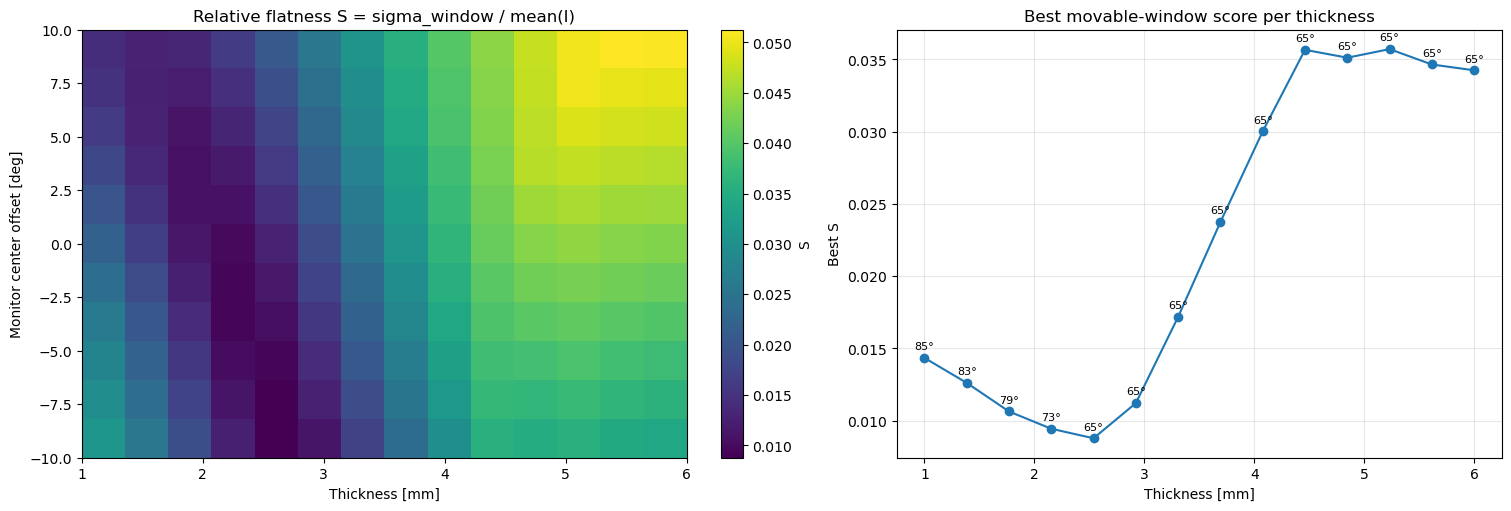

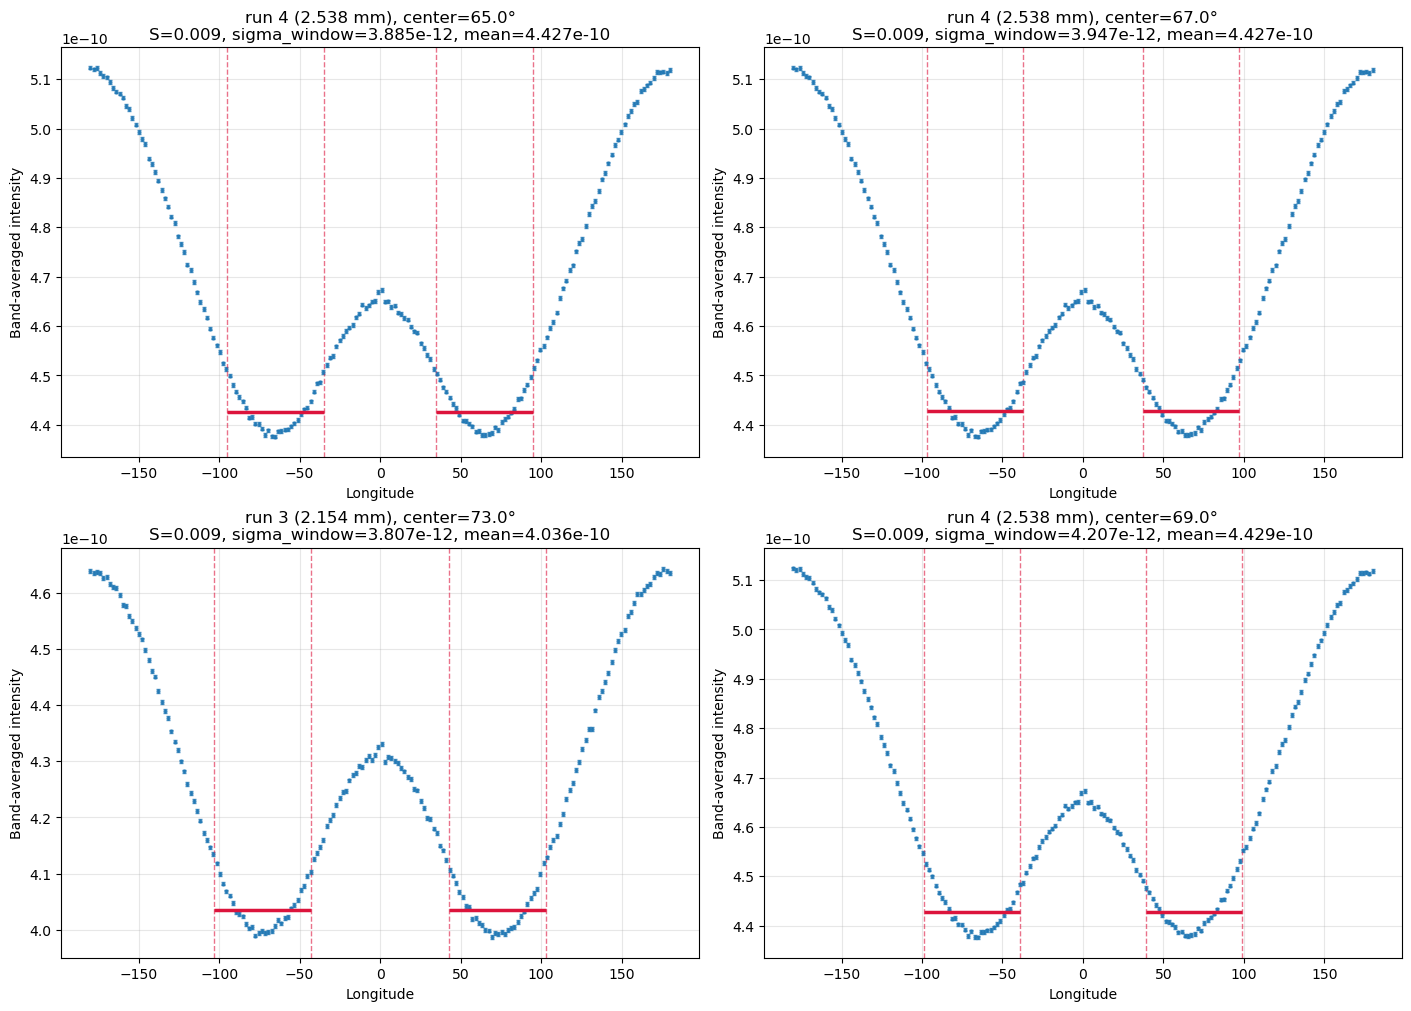

In [64]:
# Movable 60 degree detector-window optimization using a relative flatness metric.
# Scores each candidate with S = sigma_window / mean(I) in the detector window.
scan_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test/1to6_r7p5mmh1cm_bathed_1e9')
run_indices = list(range(14))
thicknesses_mm = np.linspace(1.0, 6.0, len(run_indices))

detector_window_width_deg = 60.0
nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-10.0, 10.1, 2.0)
low_outlier_fraction = 0.9
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0


def get_equator_cut_sigma(run_path):
    sphere_mon = ms.load_data(str(run_path))[2]
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    # Remove zero bins from the McStas angular filter before averaging.
    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def relative_flatness_score(lon, y, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    x_fit = lon[fit_mask]
    y_fit = np.asarray(y)[fit_mask]
    y_fit = y_fit[np.isfinite(y_fit) & (y_fit > 0)]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)
    s_value = sigma_window / mean_window if mean_window > 0 else np.nan

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'S': s_value,
        'n_points': len(y_fit),
    }

all_results_sigma = []
best_by_thickness_sigma = []

for run_idx, thickness_mm in zip(run_indices, thicknesses_mm):
    lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_sigma(scan_root / str(run_idx))

    run_scores = []
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = relative_flatness_score(lon, equator_cut, valid_cols, center_deg)
        if score is None:
            continue
        score.update({
            'run_idx': run_idx,
            'thickness_mm': thickness_mm,
            'offset_deg': offset_deg,
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
        })
        run_scores.append(score)
        all_results_sigma.append(score)

    best_by_thickness_sigma.append(min(run_scores, key=lambda r: r['S']))

best_overall_sigma = min(all_results_sigma, key=lambda r: r['S'])
print(
    f"Best movable-window result by S=sigma/mean: run {best_overall_sigma['run_idx']} "
    f"({best_overall_sigma['thickness_mm']:.3f} mm), center={best_overall_sigma['center_deg']:.1f} deg "
    f"(offset {best_overall_sigma['offset_deg']:+.1f} deg), S={best_overall_sigma['S']:.4f}, "
    f"sigma_window={best_overall_sigma['sigma_window']:.3e}, mean_window={best_overall_sigma['mean_window']:.3e}, "
    f"n={best_overall_sigma['n_points']}"
)

print("\nBest monitor center for each thickness:")
for r in best_by_thickness_sigma:
    print(
        f"thickness={r['thickness_mm']:.3f} mm: center={r['center_deg']:.1f} deg "
        f"(offset {r['offset_deg']:+.1f}), S={r['S']:.4f}, sigma={r['sigma_window']:.3e}, mean={r['mean_window']:.3e}"
    )

# Percentage spread within detector window for best overall.
r = best_overall_sigma
lon_plot = r['lon_plot']
vals = r['equator_cut_plot']
pos_mask = (lon_plot >= r['pos_min']) & (lon_plot <= r['pos_max'])
neg_mask = (lon_plot >= r['neg_min']) & (lon_plot <= r['neg_max'])
window_mask = pos_mask | neg_mask
vals_in_window = np.array(vals)[window_mask]
valid_mask = np.isfinite(vals_in_window) & (vals_in_window > 0)
if np.any(valid_mask):
    mx = np.nanmax(vals_in_window[valid_mask])
    mn = np.nanmin(vals_in_window[valid_mask])
    pct_diff = 100.0 * (mx - mn) / mx if mx > 0 else 0.0
    print(f"Pct diff within detector window (best overall): {pct_diff:.3f}% (max={mx:.3e}, min={mn:.3e})")
else:
    print("No valid positive intensities in detector window for best overall.")

# Heatmap: S as function of detector-center offset and thickness.
heatmap = np.full((len(center_offsets_deg), len(thicknesses_mm)), np.nan)
for r in all_results_sigma:
    i = np.where(center_offsets_deg == r['offset_deg'])[0][0]
    j = np.where(np.isclose(thicknesses_mm, r['thickness_mm']))[0][0]
    heatmap[i, j] = r['S']

fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axs[0].imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[thicknesses_mm[0], thicknesses_mm[-1], center_offsets_deg[0], center_offsets_deg[-1]],
    cmap='viridis',
)
axs[0].set_xlabel('Thickness [mm]')
axs[0].set_ylabel('Monitor center offset [deg]')
axs[0].set_title('Relative flatness S = sigma_window / mean(I)')
fig.colorbar(im, ax=axs[0], label='S')

axs[1].plot(
    [r['thickness_mm'] for r in best_by_thickness_sigma],
    [r['S'] for r in best_by_thickness_sigma],
    'o-',
)
for r in best_by_thickness_sigma:
    axs[1].annotate(f"{r['center_deg']:.0f}°", (r['thickness_mm'], r['S']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axs[1].set_xlabel('Thickness [mm]')
axs[1].set_ylabel('Best S')
axs[1].set_title('Best movable-window score per thickness')
axs[1].grid(True, alpha=0.3)
plt.show()

# Inspect best four movable-window candidates.
best_four = sorted(all_results_sigma, key=lambda r: r['S'])[:4]
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.ravel()

for ax, r in zip(axs, best_four):
    ax.errorbar(
        r['lon_plot'],
        r['equator_cut_plot'],
        yerr=r['equator_cut_err_plot'],
        fmt='o',
        ms=2,
        elinewidth=0.8,
        capsize=1.5,
        alpha=0.8,
    )
    window_const = np.nanmean(r['equator_cut_plot'][(r['lon_plot'] >= r['pos_min']) & (r['lon_plot'] <= r['pos_max']) | (r['lon_plot'] >= r['neg_min']) & (r['lon_plot'] <= r['neg_max'])])
    ax.hlines(window_const, r['pos_min'], r['pos_max'], color='crimson', lw=2.5, zorder=5)
    ax.hlines(window_const, r['neg_min'], r['neg_max'], color='crimson', lw=2.5, zorder=5)
    for xline in [r['pos_min'], r['pos_max'], r['neg_min'], r['neg_max']]:
        ax.axvline(xline, color='crimson', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Band-averaged intensity')
    ax.set_title(
        f"run {r['run_idx']} ({r['thickness_mm']:.3f} mm), center={r['center_deg']:.1f}°\n"
        f"S={r['S']:.3f}, sigma_window={r['sigma_window']:.3e}, mean={r['mean_window']:.3e}"
    )
    ax.grid(True, alpha=0.3)

plt.show()


# optimization over all 3 varaibles using the intensity normalized flatness test. files are found using the metadata in mccode.sim

Parsed runs: 582
Best by S: r=5.00 mm, h=50.00 mm,t=1.00 mm, offset=+0.0 deg, S=0.00065, sigma_window=5.260e-12, mean_window=8.113e-09

Top 12 by S:
1. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=+0.0 deg, S=0.00065, sigma_window=5.260e-12, mean_window=8.113e-09
2. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-2.0 deg, S=0.00078, sigma_window=4.193e-12, mean_window=5.384e-09
3. r=7.50 mm, h=20.00 mm, t=2.00 mm, offset=-30.0 deg, S=0.00082, sigma_window=2.268e-12, mean_window=2.765e-09
4. r=14.00 mm, h=50.00 mm, t=2.62 mm, offset=-20.0 deg, S=0.00088, sigma_window=6.273e-11, mean_window=7.126e-08
5. r=14.00 mm, h=45.00 mm, t=2.62 mm, offset=-26.0 deg, S=0.00088, sigma_window=5.214e-11, mean_window=5.896e-08
6. r=10.00 mm, h=50.00 mm, t=2.00 mm, offset=-14.0 deg, S=0.00091, sigma_window=3.378e-11, mean_window=3.723e-08
7. r=15.00 mm, h=50.00 mm, t=2.88 mm, offset=-30.0 deg, S=0.00092, sigma_window=7.481e-11, mean_window=8.164e-08
8. r=13.00 mm, h=50.00 mm, t=2.50 mm, offset=-22.0 deg, S=0.00098

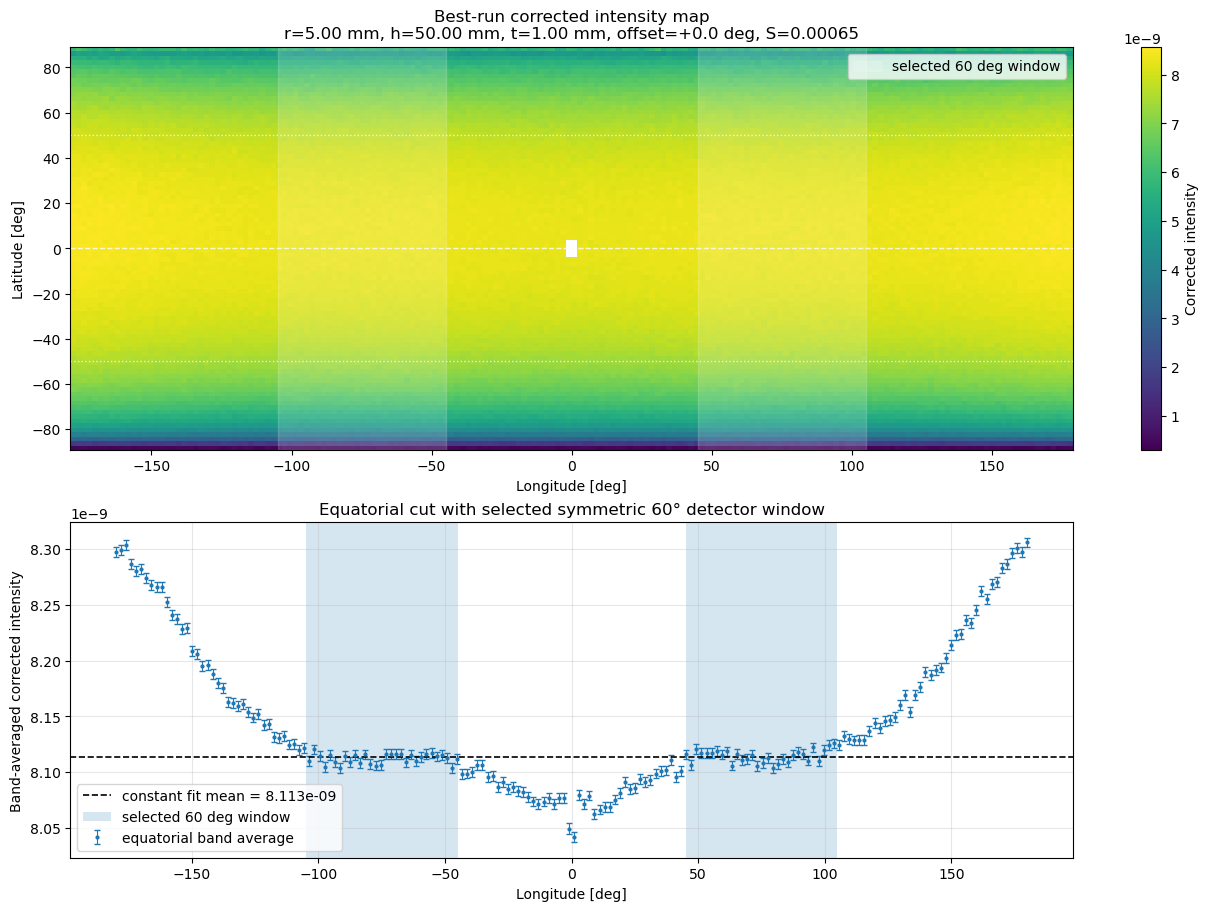

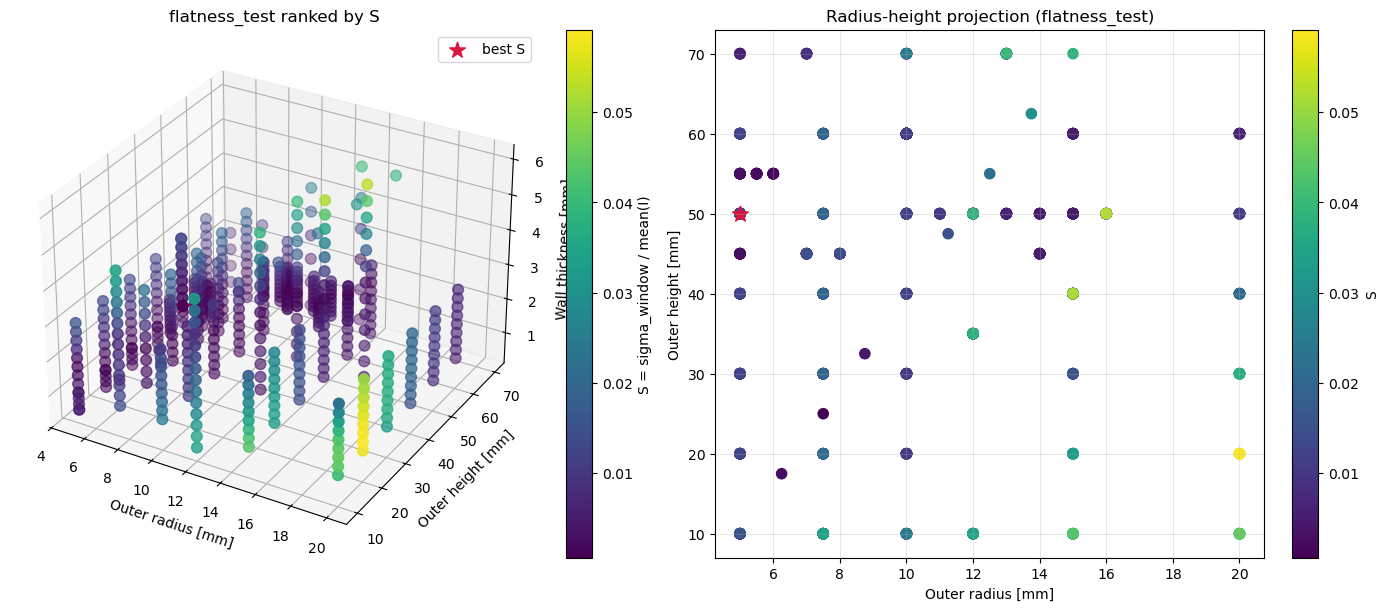

In [ ]:
# Flatness test S on flatness_test data, using geometry values from mccode.sim.
# Folder layout: flatness_test/<geometry_folder>/<run_idx>/
# Each run folder must contain mccode.sim and cylinder_scattered.dat.


flatness_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test')
nominal_detector_center_deg = 75.0

center_offsets_deg = np.arange(-30.0, 30.1, 2.0)

detector_window_width_deg = 60.0
low_outlier_fraction = 0.0
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0
I_ref = 1e-8
penalty_crit = 0.001
penalty_switch = False


def parse_mccode_sim(sim_file):
    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [k for k in required if k not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    # Stored in meters in mccode.sim; convert to mm.
    return {
        'outer_radius_mm': params['cylinder_radius'] * 1000.0,
        'outer_height_mm': params['cylinder_height'] * 1000.0,
        'wall_thickness_mm': params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    # Prefer the 4pi scattered monitor by filename/component name when available.
    for item in loaded:
        name = str(getattr(item, 'name', '') or '')
        component = str(getattr(item, 'component_name', '') or '')
        if 'cylinder_scattered' in name or 'mon_4pi' in component:
            return item

    # Fallback to the third item or last available item.
    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_equator_cut_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def s_score(lon, y, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max)))
    y_fit = np.asarray(y)[fit_mask]
    y_fit = y_fit[np.isfinite(y_fit) & (y_fit > 0)]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)
    s_value = sigma_window / mean_window if mean_window > 0 else np.nan
    # s_value *= 0.35 * np.exp(-mean_window / I_ref - 1)  # Penalize low mean values.
    if penalty_switch:
        penalty = penalty_crit * np.exp(-(mean_window / I_ref - 1.0))
    else:
        penalty = 0.0
    s_value += penalty

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'S': s_value,
        'n_points': len(y_fit),
    }


sim_files = sorted(flatness_root.glob('**/mccode.sim'))
records = []

for sim_file in sim_files:
    run_dir = sim_file.parent
    scatter_file = run_dir / 'cylinder_scattered.dat'
    if not scatter_file.exists():
        continue

    try:
        geom = parse_mccode_sim(sim_file)
        lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(run_dir)
    except Exception:
        continue

    best_local = None
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = s_score(lon, equator_cut, valid_cols, center_deg)
        if score is None:
            continue

        score.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
            **geom,
        })

        if best_local is None or score['S'] < best_local['S']:
            best_local = score

    if best_local is not None:
        records.append(best_local)

# Sort by mccode.sim geometry values first, then by score.
records_sorted_by_geom = sorted(
    records,
    key=lambda r: (r['outer_radius_mm'], r['outer_height_mm'], r['wall_thickness_mm'], r['S'])
)
records_by_score = sorted(records, key=lambda r: r['S'])



print(f'Parsed runs: {len(records_by_score)}')
if records_by_score:
    best = records_by_score[0]
    print(
        f"Best by S: r={best['outer_radius_mm']:.2f} mm, h={best['outer_height_mm']:.2f} mm,"
        f"t={best['wall_thickness_mm']:.2f} mm, offset={best['offset_deg']:+.1f} deg, "
        f"S={best['S']:.5f}, sigma_window={best['sigma_window']:.3e}, mean_window={best['mean_window']:.3e}"
    )

    print('\nTop 12 by S:')
    for i, r in enumerate(records_by_score[:12], start=1):
        print(
            f"{i}. r={r['outer_radius_mm']:.2f} mm, h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, offset={r['offset_deg']:+.1f} deg, S={r['S']:.5f}, "
            f"sigma_window={r['sigma_window']:.3e}, mean_window={r['mean_window']:.3e}"
        )

    # ------------------------------------------------------------
    # Plot best-run 4pi intensity heat map + equator cut with window
    # ------------------------------------------------------------

    def get_corrected_heatmap_from_run(run_dir):
        sphere_mon = load_scattered_monitor(run_dir)
        meta = sphere_mon.metadata

        H = np.array(sphere_mon.Intensity, copy=True)
        H_err = np.array(sphere_mon.Error, copy=True)

        if hasattr(meta, 'dimension') and H.shape == (meta.dimension[0], meta.dimension[1]):
            H = H.T
            H_err = H_err.T

        xmin, xmax, ymin, ymax = meta.limits

        lat_centers = np.linspace(
            ymin + 0.5 * (ymax - ymin) / H.shape[0],
            ymax - 0.5 * (ymax - ymin) / H.shape[0],
            H.shape[0],
        )
        lon_centers = np.linspace(
            xmin + 0.5 * (xmax - xmin) / H.shape[1],
            xmax - 0.5 * (xmax - xmin) / H.shape[1],
            H.shape[1],
        )

        cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
        safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

        H_corr = H / safe_cos
        H_err_corr = H_err / safe_cos

        Lon, Lat = np.meshgrid(lon_centers, lat_centers)

        beam_center_mask = (
            (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
            (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
        )

        H_corr = np.where(~beam_center_mask, H_corr, np.nan)
        H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

        return lon_centers, lat_centers, H_corr, H_err_corr


    best_run_dir = Path(best['run_dir'])

    lon_best, lat_best, H_best, H_best_err = get_corrected_heatmap_from_run(best_run_dir)

    # Recompute equator cut for the best run, keeping full longitude array.
    lon_cut, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(best_run_dir)

    fig, (ax_map, ax_cut) = plt.subplots(
        2, 1,
        figsize=(12, 9),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1.2, 1.0]}
    )

    # -----------------------------
    # 1. Corrected 4pi heat map
    # -----------------------------
    im = ax_map.imshow(
        H_best,
        origin='lower',
        aspect='auto',
        extent=[lon_best.min(), lon_best.max(), lat_best.min(), lat_best.max()],
        interpolation='nearest',
        cmap='viridis',
    )

    ax_map.axhline(0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)

    # Mark equatorial averaging band
    ax_map.axhline(+equator_band_halfwidth_local, color='white', linestyle=':', linewidth=1.0, alpha=0.8)
    ax_map.axhline(-equator_band_halfwidth_local, color='white', linestyle=':', linewidth=1.0, alpha=0.8)

    # Mark selected positive and negative 60 deg windows
    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:
        ax_map.axvspan(
            xmin_win,
            xmax_win,
            color='white',
            alpha=0.16,
            label='selected 60 deg window' if xmin_win == best['pos_min'] else None,
        )

    ax_map.set_xlabel('Longitude [deg]')
    ax_map.set_ylabel('Latitude [deg]')
    ax_map.set_title(
        'Best-run corrected intensity map\n'
        f"r={best['outer_radius_mm']:.2f} mm, "
        f"h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, "
        f"offset={best['offset_deg']:+.1f} deg, "
        f"S={best['S']:.5f}"
    )

    cbar = fig.colorbar(im, ax=ax_map)
    cbar.set_label('Corrected intensity')

    ax_map.legend(loc='upper right')


    # -----------------------------
    # 2. Equator cut with window
    # -----------------------------
    ax_cut.errorbar(
        lon_cut[valid_cols],
        equator_cut[valid_cols],
        yerr=equator_cut_err[valid_cols],
        fmt='.',
        markersize=4,
        capsize=2,
        linewidth=0.8,
        label='equatorial band average',
    )

    # Constant fit value in selected window
    fit_mask = valid_cols & (
        ((lon_cut >= best['pos_min']) & (lon_cut <= best['pos_max'])) |
        ((lon_cut >= best['neg_min']) & (lon_cut <= best['neg_max']))
    )

    fit_mean = np.nanmean(equator_cut[fit_mask])

    ax_cut.axhline(
        fit_mean,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'constant fit mean = {fit_mean:.3e}',
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:
        ax_cut.axvspan(
            xmin_win,
            xmax_win,
            alpha=0.18,
            label='selected 60 deg window' if xmin_win == best['pos_min'] else None,
        )

    ax_cut.set_xlabel('Longitude [deg]')
    ax_cut.set_ylabel('Band-averaged corrected intensity')
    ax_cut.set_title('Equatorial cut with selected symmetric 60° detector window')
    ax_cut.grid(True, alpha=0.3)
    ax_cut.legend()

    plt.show()

    

    fig = plt.figure(figsize=(14, 6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    sc = ax3d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        [r['wall_thickness_mm'] for r in records_by_score],
        c=[r['S'] for r in records_by_score],
        cmap='viridis',
        s=60,
    )
    ax3d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        best['wall_thickness_mm'],
        color='crimson',
        marker='*',
        s=140,
        label='best S',
    )
    ax3d.set_xlabel('Outer radius [mm]')
    ax3d.set_ylabel('Outer height [mm]')
    ax3d.set_zlabel('Wall thickness [mm]')
    ax3d.set_title('flatness_test ranked by S')
    ax3d.legend()
    fig.colorbar(sc, ax=ax3d, label='S = sigma_window / mean(I)')

    ax2d = fig.add_subplot(1, 2, 2)
    proj = ax2d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        c=[r['S'] for r in records_by_score],
        cmap='viridis',
        s=70,
        edgecolor='none',
    )
    ax2d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        color='crimson',
        marker='*',
        s=140,
    )
    ax2d.set_xlabel('Outer radius [mm]')
    ax2d.set_ylabel('Outer height [mm]')
    ax2d.set_title('Radius-height projection (flatness_test)')
    ax2d.grid(True, alpha=0.3)
    fig.colorbar(proj, ax=ax2d, label='S')

    plt.show()
else:
    print('No valid runs found in flatness_test with both mccode.sim and cylinder_scattered.dat.')


Parsed runs: 582
Best by reduced chi2: r=5.00 mm, h=60.00 mm, t=0.67 mm, offset=+14.0 deg, red_chi2=0.59431, chi2=3.506e+01, dof=59, fit_constant=6.652e-09, sigma_window=1.120e-11, mean_window=6.652e-09

Top 12 by reduced chi2:
1. r=5.00 mm, h=60.00 mm, t=0.67 mm, offset=+14.0 deg, red_chi2=0.59431, chi2=3.506e+01, dof=59, fit_constant=6.652e-09, sigma_window=1.120e-11, mean_window=6.652e-09
2. r=5.00 mm, h=50.00 mm, t=0.83 mm, offset=+14.0 deg, red_chi2=0.62619, chi2=3.695e+01, dof=59, fit_constant=5.484e-09, sigma_window=7.970e-12, mean_window=5.484e-09
3. r=5.00 mm, h=30.00 mm, t=1.00 mm, offset=+0.0 deg, red_chi2=0.79007, chi2=4.661e+01, dof=59, fit_constant=2.317e-09, sigma_window=2.780e-12, mean_window=2.317e-09
4. r=5.00 mm, h=30.00 mm, t=1.00 mm, offset=-8.0 deg, red_chi2=0.79511, chi2=4.691e+01, dof=59, fit_constant=2.317e-09, sigma_window=2.788e-12, mean_window=2.317e-09
5. r=5.00 mm, h=60.00 mm, t=0.50 mm, offset=+14.0 deg, red_chi2=0.81797, chi2=4.826e+01, dof=59, fit_const

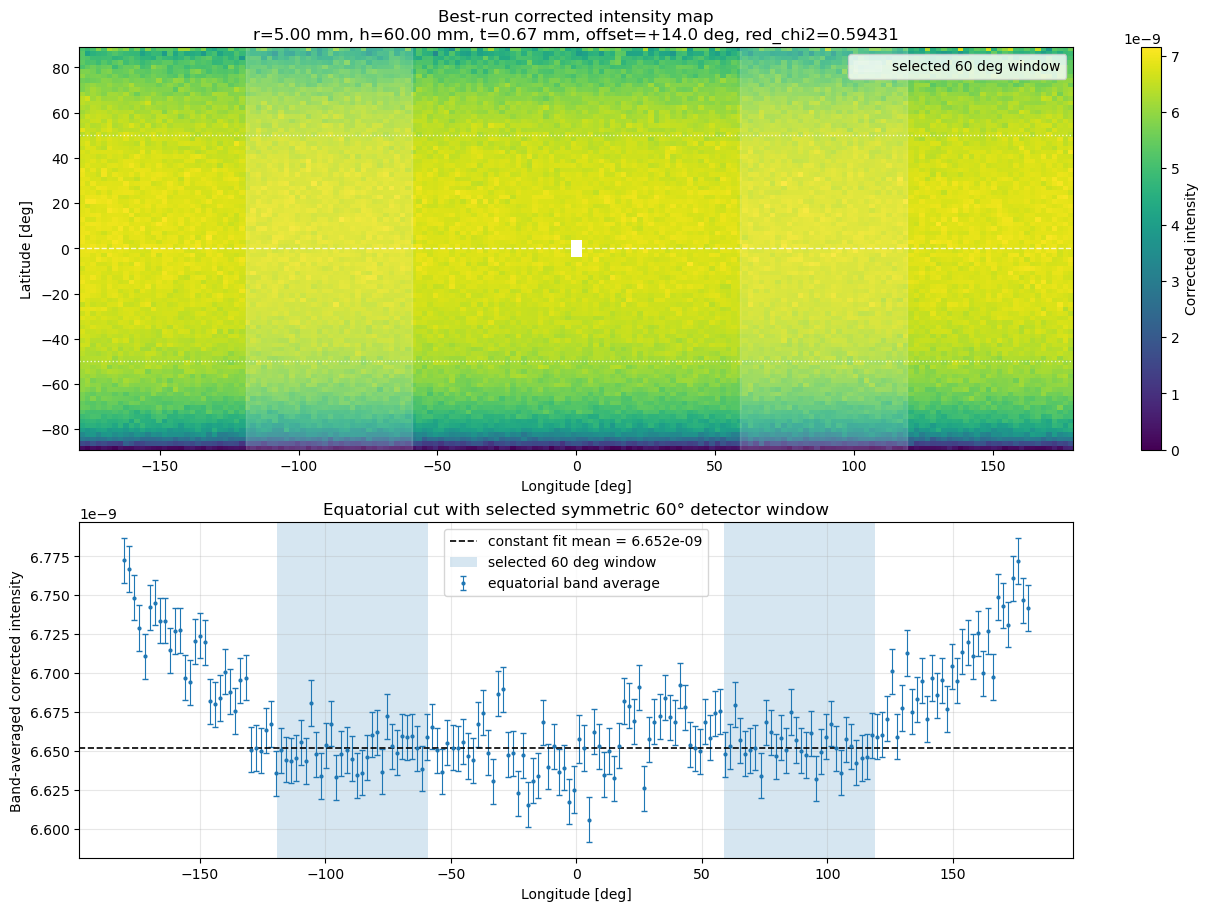

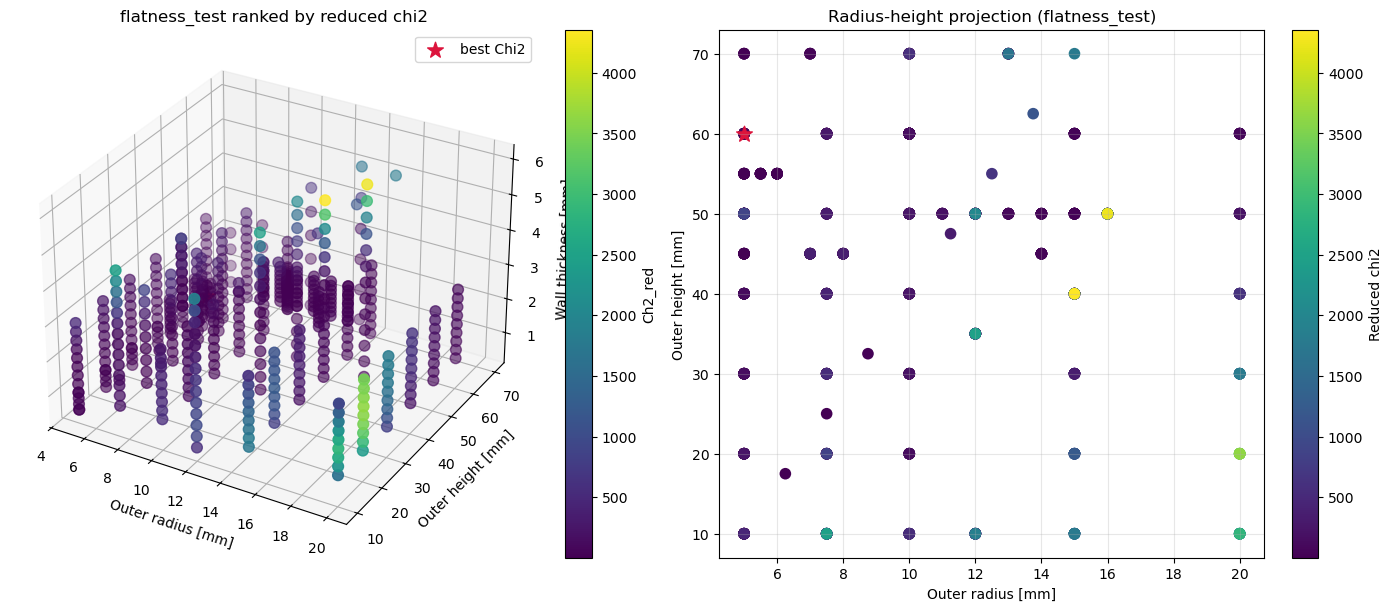

In [66]:
# Flatness test S on flatness_test data, using geometry values from mccode.sim.
# Folder layout: flatness_test/<geometry_folder>/<run_idx>/
# Each run folder must contain mccode.sim and cylinder_scattered.dat.


flatness_root = Path('/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test')
nominal_detector_center_deg = 75.0

center_offsets_deg = np.arange(-30.0, 30.1, 2.0)

detector_window_width_deg = 60.0
low_outlier_fraction = 0.0
equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0
I_ref = 1e-8
penalty_crit = 1
penalty_switch = False


def parse_mccode_sim(sim_file):
    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [k for k in required if k not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    # Stored in meters in mccode.sim; convert to mm.
    return {
        'outer_radius_mm': params['cylinder_radius'] * 1000.0,
        'outer_height_mm': params['cylinder_height'] * 1000.0,
        'wall_thickness_mm': params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    # Prefer the 4pi scattered monitor by filename/component name when available.
    for item in loaded:
        name = str(getattr(item, 'name', '') or '')
        component = str(getattr(item, 'component_name', '') or '')
        if 'cylinder_scattered' in name or 'mon_4pi' in component:
            return item

    # Fallback to the third item or last available item.
    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_equator_cut_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(xmin, xmax, Hmc.shape[1])

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    equator_cut = np.nanmean(equator_band, axis=0)
    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(np.nansum(equator_band_err**2, axis=0)) / valid_counts,
        np.nan,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
    valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def reduced_chi2_score(lon, y, yerr, valid_cols, center_deg):
    half_width = detector_window_width_deg / 2.0
    pos_min = center_deg - half_width
    pos_max = center_deg + half_width
    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (
        ((lon >= pos_min) & (lon <= pos_max)) |
        ((lon >= neg_min) & (lon <= neg_max))
    )

    y_fit = np.asarray(y)[fit_mask]
    yerr_fit = np.asarray(yerr)[fit_mask]

    good = (
        np.isfinite(y_fit) &
        np.isfinite(yerr_fit) &
        (y_fit > 0) &
        (yerr_fit > 0)
    )

    y_fit = y_fit[good]
    yerr_fit = yerr_fit[good]

    if y_fit.size < 2:
        return None

    # Weighted constant fit: y = c
    weights = 1.0 / yerr_fit**2
    c_fit = np.sum(weights * y_fit) / np.sum(weights)

    chi2 = np.sum(((y_fit - c_fit) / yerr_fit)**2)
    dof = y_fit.size - 1
    red_chi2 = chi2 / dof if dof > 0 else np.nan
    if penalty_switch:
        penalty = penalty_crit * np.exp(-(c_fit / I_ref - 1.0))
    else:
        penalty = 0.0
    red_chi2 += penalty

    mean_window = np.mean(y_fit)
    sigma_window = np.std(y_fit, ddof=1)

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'fit_constant': c_fit,
        'chi2': chi2,
        'dof': dof,
        'red_chi2': red_chi2,
        'mean_window': mean_window,
        'sigma_window': sigma_window,
        'n_points': len(y_fit),
    }


sim_files = sorted(flatness_root.glob('**/mccode.sim'))
records = []

for sim_file in sim_files:
    run_dir = sim_file.parent
    scatter_file = run_dir / 'cylinder_scattered.dat'
    if not scatter_file.exists():
        continue

    try:
        geom = parse_mccode_sim(sim_file)
        lon, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(run_dir)
    except Exception:
        continue

    best_local = None
    for offset_deg in center_offsets_deg:
        center_deg = nominal_detector_center_deg + offset_deg
        score = reduced_chi2_score(lon, equator_cut, equator_cut_err, valid_cols, center_deg)
        if score is None:
            continue

        score.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            'lon_plot': lon[valid_cols],
            'equator_cut_plot': equator_cut[valid_cols],
            'equator_cut_err_plot': equator_cut_err[valid_cols],
            **geom,
        })

        if best_local is None or score['red_chi2'] < best_local['red_chi2']:
            best_local = score

    if best_local is not None:
        records.append(best_local)

# Sort by mccode.sim geometry values first, then by score.
records_sorted_by_geom = sorted(
    records,
    key=lambda r: (
        r['outer_radius_mm'],
        r['outer_height_mm'],
        r['wall_thickness_mm'],
        r['red_chi2'],
    )
)
records_by_score = sorted(records, key=lambda r: r['red_chi2'])

print(f'Parsed runs: {len(records_by_score)}')
if records_by_score:
    best = records_by_score[0]
    print(
        f"Best by reduced chi2: r={best['outer_radius_mm']:.2f} mm, "
        f"h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, "
        f"offset={best['offset_deg']:+.1f} deg, "
        f"red_chi2={best['red_chi2']:.5f}, "
        f"chi2={best['chi2']:.3e}, dof={best['dof']}, "
        f"fit_constant={best['fit_constant']:.3e}, "
        f"sigma_window={best['sigma_window']:.3e}, "
        f"mean_window={best['mean_window']:.3e}"
    )

    print('\nTop 12 by reduced chi2:')
    for i, r in enumerate(records_by_score[:12], start=1):
        print(
            f"{i}. r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"red_chi2={r['red_chi2']:.5f}, "
            f"chi2={r['chi2']:.3e}, dof={r['dof']}, "
            f"fit_constant={r['fit_constant']:.3e}, "
            f"sigma_window={r['sigma_window']:.3e}, "
            f"mean_window={r['mean_window']:.3e}"
        )

    # ------------------------------------------------------------
    # Plot best-run 4pi intensity heat map + equator cut with window
    # ------------------------------------------------------------

    def get_corrected_heatmap_from_run(run_dir):
        sphere_mon = load_scattered_monitor(run_dir)
        meta = sphere_mon.metadata

        H = np.array(sphere_mon.Intensity, copy=True)
        H_err = np.array(sphere_mon.Error, copy=True)

        if hasattr(meta, 'dimension') and H.shape == (meta.dimension[0], meta.dimension[1]):
            H = H.T
            H_err = H_err.T

        xmin, xmax, ymin, ymax = meta.limits

        lat_centers = np.linspace(
            ymin + 0.5 * (ymax - ymin) / H.shape[0],
            ymax - 0.5 * (ymax - ymin) / H.shape[0],
            H.shape[0],
        )
        lon_centers = np.linspace(
            xmin + 0.5 * (xmax - xmin) / H.shape[1],
            xmax - 0.5 * (xmax - xmin) / H.shape[1],
            H.shape[1],
        )

        cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
        safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

        H_corr = H / safe_cos
        H_err_corr = H_err / safe_cos

        Lon, Lat = np.meshgrid(lon_centers, lat_centers)

        beam_center_mask = (
            (np.abs(Lon) <= beam_lon_halfwidth_deg_local) &
            (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
        )

        H_corr = np.where(~beam_center_mask, H_corr, np.nan)
        H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

        return lon_centers, lat_centers, H_corr, H_err_corr


    best_run_dir = Path(best['run_dir'])

    lon_best, lat_best, H_best, H_best_err = get_corrected_heatmap_from_run(best_run_dir)

    # Recompute equator cut for the best run, keeping full longitude array.
    lon_cut, equator_cut, equator_cut_err, valid_cols = get_equator_cut_from_run(best_run_dir)

    fig, (ax_map, ax_cut) = plt.subplots(
        2, 1,
        figsize=(12, 9),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1.2, 1.0]}
    )

    # -----------------------------
    # 1. Corrected 4pi heat map
    # -----------------------------
    im = ax_map.imshow(
        H_best,
        origin='lower',
        aspect='auto',
        extent=[lon_best.min(), lon_best.max(), lat_best.min(), lat_best.max()],
        interpolation='nearest',
        cmap='viridis',
    )

    ax_map.axhline(0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)

    # Mark equatorial averaging band
    ax_map.axhline(+equator_band_halfwidth_local, color='white', linestyle=':', linewidth=1.0, alpha=0.8)
    ax_map.axhline(-equator_band_halfwidth_local, color='white', linestyle=':', linewidth=1.0, alpha=0.8)

    # Mark selected positive and negative 60 deg windows
    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:
        ax_map.axvspan(
            xmin_win,
            xmax_win,
            color='white',
            alpha=0.16,
            label='selected 60 deg window' if xmin_win == best['pos_min'] else None,
        )

    ax_map.set_xlabel('Longitude [deg]')
    ax_map.set_ylabel('Latitude [deg]')
    ax_map.set_title(
        'Best-run corrected intensity map\n'
        f"r={best['outer_radius_mm']:.2f} mm, "
        f"h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, "
        f"offset={best['offset_deg']:+.1f} deg, "
        f"red_chi2={best['red_chi2']:.5f}"
    )

    cbar = fig.colorbar(im, ax=ax_map)
    cbar.set_label('Corrected intensity')

    ax_map.legend(loc='upper right')


    # -----------------------------
    # 2. Equator cut with window
    # -----------------------------
    ax_cut.errorbar(
        lon_cut[valid_cols],
        equator_cut[valid_cols],
        yerr=equator_cut_err[valid_cols],
        fmt='.',
        markersize=4,
        capsize=2,
        linewidth=0.8,
        label='equatorial band average',
    )

    # Constant fit value in selected window
    fit_mask = valid_cols & (
        ((lon_cut >= best['pos_min']) & (lon_cut <= best['pos_max'])) |
        ((lon_cut >= best['neg_min']) & (lon_cut <= best['neg_max']))
    )

    fit_mean = best['fit_constant']

    ax_cut.axhline(
        fit_mean,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'constant fit mean = {fit_mean:.3e}',
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:
        ax_cut.axvspan(
            xmin_win,
            xmax_win,
            alpha=0.18,
            label='selected 60 deg window' if xmin_win == best['pos_min'] else None,
        )

    ax_cut.set_xlabel('Longitude [deg]')
    ax_cut.set_ylabel('Band-averaged corrected intensity')
    ax_cut.set_title('Equatorial cut with selected symmetric 60° detector window')
    ax_cut.grid(True, alpha=0.3)
    ax_cut.legend()

    plt.show()

    

    fig = plt.figure(figsize=(14, 6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    sc = ax3d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        [r['wall_thickness_mm'] for r in records_by_score],
        c=[r['red_chi2'] for r in records_by_score],
        cmap='viridis',
        s=60,
    )
    ax3d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        best['wall_thickness_mm'],
        color='crimson',
        marker='*',
        s=140,
        label='best Chi2',
    )
    ax3d.set_xlabel('Outer radius [mm]')
    ax3d.set_ylabel('Outer height [mm]')
    ax3d.set_zlabel('Wall thickness [mm]')
    ax3d.set_title('flatness_test ranked by reduced chi2')
    ax3d.legend()
    fig.colorbar(sc, ax=ax3d, label='Ch2_red')

    ax2d = fig.add_subplot(1, 2, 2)
    proj = ax2d.scatter(
        [r['outer_radius_mm'] for r in records_by_score],
        [r['outer_height_mm'] for r in records_by_score],
        c=[r['red_chi2'] for r in records_by_score],
        cmap='viridis',
        s=70,
        edgecolor='none',
    )
    ax2d.scatter(
        best['outer_radius_mm'],
        best['outer_height_mm'],
        color='crimson',
        marker='*',
        s=140,
    )
    ax2d.set_xlabel('Outer radius [mm]')
    ax2d.set_ylabel('Outer height [mm]')
    ax2d.set_title('Radius-height projection (flatness_test)')
    ax2d.grid(True, alpha=0.3)
    fig.colorbar(proj, ax=ax2d, label='Reduced chi2')

    plt.show()
else:
    print('No valid runs found in flatness_test with both mccode.sim and cylinder_scattered.dat.')


# fitted optimum on the brute force simulations

Parsed runs: 678

--------------------------------------------------
Best sampled geometry
--------------------------------------------------
r = 5.00 mm, h = 50.00 mm, t = 1.00 mm
S = 0.000648, offset = +0.0 deg

--------------------------------------------------
RBF response-surface optimization
--------------------------------------------------
Radius      = 5.031 mm
Height      = 50.010 mm
Thickness   = 1.064 mm
Predicted S = 0.001041
Fit RMSE    = 1.017963e-04

Top 12 by S:
1. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=+0.0 deg, S=0.00065, sigma=5.260e-12, mean=8.113e-09
2. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-2.0 deg, S=0.00078, sigma=4.193e-12, mean=5.384e-09
3. r=5.00 mm, h=50.00 mm, t=0.98 mm, offset=-4.0 deg, S=0.00080, sigma=6.490e-12, mean=8.090e-09
4. r=7.50 mm, h=20.00 mm, t=2.00 mm, offset=-30.0 deg, S=0.00082, sigma=2.268e-12, mean=2.765e-09
5. r=5.00 mm, h=50.00 mm, t=1.04 mm, offset=-2.0 deg, S=0.00085, sigma=7.108e-12, mean=8.397e-09
6. r=5.00 mm, h=50.00 mm, t=1.

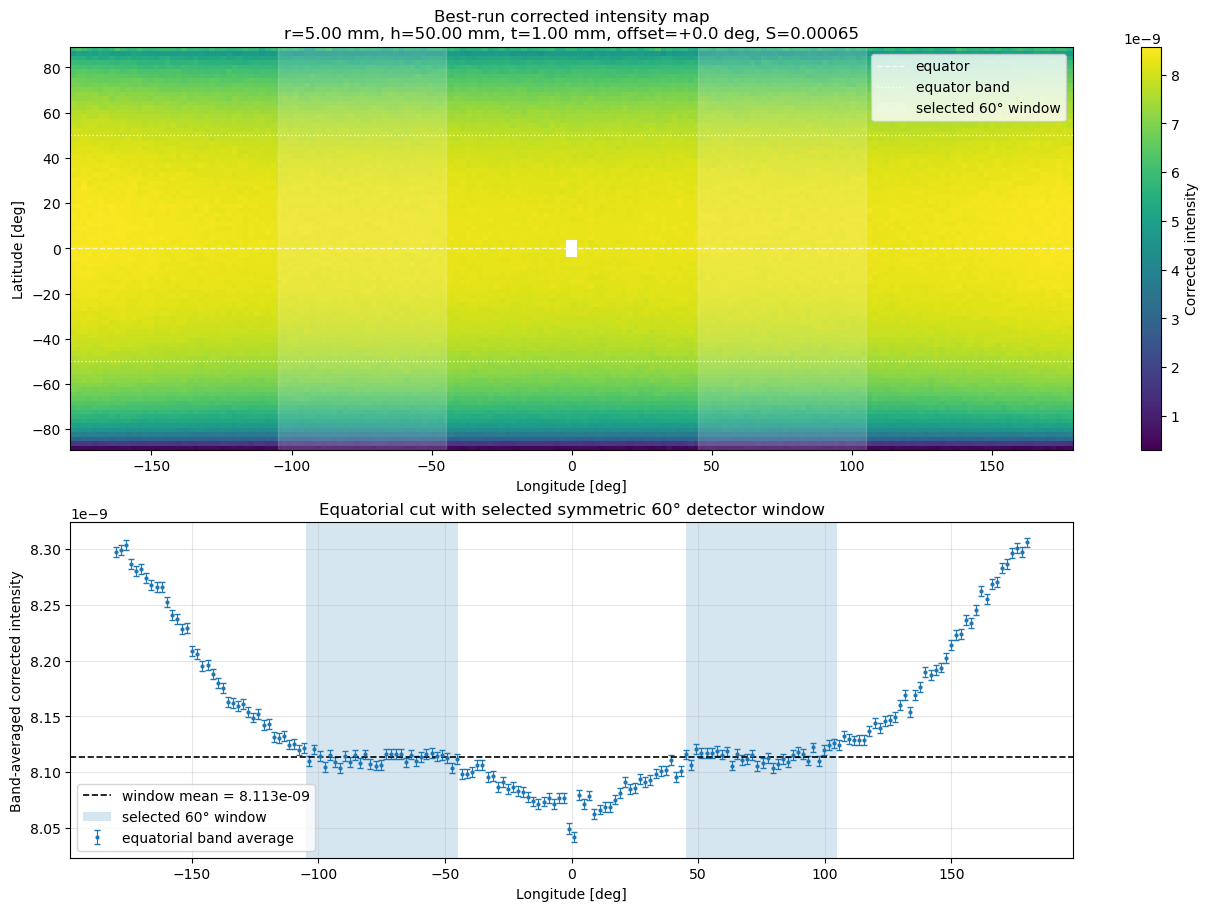

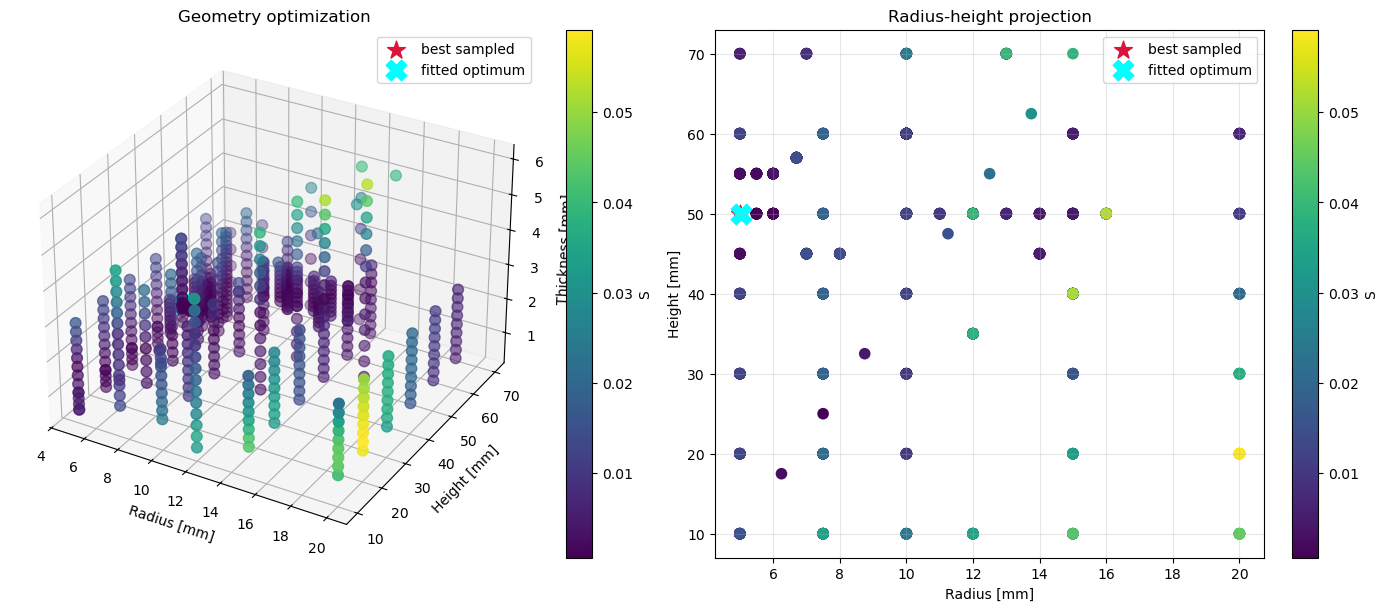

In [82]:
# ============================================================
# Flatness analysis + 'RBF response-surface optimization'
# ============================================================

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# ============================================================
# User settings
# ============================================================

flatness_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/'
    'geometry_optimization/cylinder_instrument/flatness_test'
)

nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-30.0, 30.1, 2.0)

detector_window_width_deg = 60.0

low_outlier_fraction = 0.0

equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0

I_ref = 5e-8

penalty_crit = 0.001
penalty_switch = False

# ============================================================
# Helper functions
# ============================================================

def get_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata

    H = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    H_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        H.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon_centers,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    H_corr = np.where(
        ~beam_center_mask,
        H_corr,
        np.nan
    )

    H_err_corr = np.where(
        ~beam_center_mask,
        H_err_corr,
        np.nan
    )

    return lon_centers, lat_centers, H_corr, H_err_corr

def parse_mccode_sim(sim_file):

    params = {}

    pattern = re.compile(
        r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$'
    )

    with sim_file.open('r') as f:

        for line in f:

            match = pattern.match(line)

            if not match:
                continue

            key = match.group(1).strip()
            raw_value = match.group(2).strip()

            try:
                params[key] = float(raw_value)

            except ValueError:
                pass

    required = [
        'cylinder_radius',
        'cylinder_height',
        'thickness'
    ]

    missing = [k for k in required if k not in params]

    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    return {
        'outer_radius_mm':
            params['cylinder_radius'] * 1000.0,

        'outer_height_mm':
            params['cylinder_height'] * 1000.0,

        'wall_thickness_mm':
            params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(
            f'No McStas data loaded from {run_dir}'
        )

    for item in loaded:

        name = str(
            getattr(item, 'name', '') or ''
        )

        component = str(
            getattr(item, 'component_name', '') or ''
        )

        if (
            'cylinder_scattered' in name or
            'mon_4pi' in component
        ):
            return item

    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_equator_cut_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)

    meta = sphere_mon.metadata

    Hmc = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    Hmc_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        Hmc.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )

    lon = np.linspace(
        xmin,
        xmax,
        Hmc.shape[1]
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    Hmc_corrected = np.where(
        ~beam_center_mask,
        Hmc_corrected,
        np.nan
    )

    Hmc_err_corrected = np.where(
        ~beam_center_mask,
        Hmc_err_corrected,
        np.nan
    )

    equator_band_mask = (
        np.abs(lat_centers)
        <= equator_band_halfwidth_local
    )

    equator_band = Hmc_corrected[
        equator_band_mask,
        :
    ]

    equator_band_err = Hmc_err_corrected[
        equator_band_mask,
        :
    ]

    nonzero_band = equator_band > 0

    equator_band = np.where(
        nonzero_band,
        equator_band,
        np.nan
    )

    equator_band_err = np.where(
        nonzero_band,
        equator_band_err,
        np.nan
    )

    equator_cut = np.nanmean(
        equator_band,
        axis=0
    )

    valid_counts = np.sum(
        ~np.isnan(equator_band),
        axis=0
    )

    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(
            np.nansum(equator_band_err**2, axis=0)
        ) / valid_counts,
        np.nan,
    )

    valid_cols = (
        (valid_counts > 0)
        &
        np.isfinite(equator_cut)
        &
        (equator_cut > 0)
    )

    low_outlier_threshold = (
        low_outlier_fraction
        *
        np.nanmedian(equator_cut[valid_cols])
    )

    valid_cols = (
        valid_cols
        &
        (equator_cut >= low_outlier_threshold)
    )

    return (
        lon,
        equator_cut,
        equator_cut_err,
        valid_cols
    )


def s_score(lon, y, valid_cols, center_deg):

    half_width = detector_window_width_deg / 2.0

    pos_min = center_deg - half_width
    pos_max = center_deg + half_width

    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (
        (
            (lon >= pos_min)
            &
            (lon <= pos_max)
        )
        |
        (
            (lon >= neg_min)
            &
            (lon <= neg_max)
        )
    )

    y_fit = np.asarray(y)[fit_mask]

    y_fit = y_fit[
        np.isfinite(y_fit)
        &
        (y_fit > 0)
    ]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)

    sigma_window = np.std(
        y_fit,
        ddof=1
    )

    s_value = (
        sigma_window / mean_window
        if mean_window > 0 else np.nan
    )

    if penalty_switch:

        penalty = (
            penalty_crit
            *
            np.exp(
                -(mean_window / I_ref - 1.0)
            )
        )

    else:

        penalty = 0.0

    s_value += penalty

    return {

        'center_deg':
            center_deg,

        'pos_min':
            pos_min,

        'pos_max':
            pos_max,

        'neg_min':
            neg_min,

        'neg_max':
            neg_max,

        'mean_window':
            mean_window,

        'sigma_window':
            sigma_window,

        'S':
            s_value,

        'penalty':
            penalty,

        'n_points':
            len(y_fit),
    }

# ============================================================
# Parse all runs
# ============================================================

sim_files = sorted(
    flatness_root.glob('**/mccode.sim')
)

records = []

for sim_file in sim_files:

    run_dir = sim_file.parent

    scatter_file = (
        run_dir / 'cylinder_scattered.dat'
    )

    if not scatter_file.exists():
        continue

    try:

        geom = parse_mccode_sim(sim_file)

        (
            lon,
            equator_cut,
            equator_cut_err,
            valid_cols
        ) = get_equator_cut_from_run(run_dir)

    except Exception:
        continue

    best_local = None

    for offset_deg in center_offsets_deg:

        center_deg = (
            nominal_detector_center_deg
            +
            offset_deg
        )

        score = s_score(
            lon,
            equator_cut,
            valid_cols,
            center_deg
        )

        if score is None:
            continue

        score.update({

            'offset_deg':
                offset_deg,

            'run_dir':
                str(run_dir),

            'geometry_dir':
                str(run_dir.parent),

            'lon_plot':
                lon[valid_cols],

            'equator_cut_plot':
                equator_cut[valid_cols],

            'equator_cut_err_plot':
                equator_cut_err[valid_cols],

            **geom,
        })

        if (
            best_local is None
            or
            score['S'] < best_local['S']
        ):
            best_local = score

    if best_local is not None:
        records.append(best_local)

# ============================================================
# Sort records
# ============================================================

records_sorted_by_geom = sorted(
    records,
    key=lambda r: (
        r['outer_radius_mm'],
        r['outer_height_mm'],
        r['wall_thickness_mm'],
        r['S']
    )
)

records_by_score = sorted(
    records,
    key=lambda r: r['S']
)

print(f'Parsed runs: {len(records_by_score)}')

# ============================================================
# Continue only if valid runs exist
# ============================================================

if not records_by_score:

    print(
        'No valid runs found in flatness_test.'
    )

else:

    # ========================================================
    # Best sampled point
    # ========================================================

    best = records_by_score[0]

    print('\n--------------------------------------------------')
    print('Best sampled geometry')
    print('--------------------------------------------------')

    print(
        f"r = {best['outer_radius_mm']:.2f} mm, "
        f"h = {best['outer_height_mm']:.2f} mm, "
        f"t = {best['wall_thickness_mm']:.2f} mm"
    )

    print(
        f"S = {best['S']:.6f}, "
        f"offset = {best['offset_deg']:+.1f} deg"
    )

    # ========================================================
    # Build RBF response surface
    # ========================================================

    from scipy.interpolate import RBFInterpolator
    from scipy.optimize import minimize

    X = np.array([
        [
            r['outer_radius_mm'],
            r['outer_height_mm'],
            r['wall_thickness_mm']
        ]
        for r in records_by_score
    ])

    y = np.array([
        r['S']
        for r in records_by_score
    ])

    # --------------------------------------------------------
    # RBF interpolator
    # --------------------------------------------------------

    rbf_model = RBFInterpolator(
        X,
        y,
        kernel='thin_plate_spline',
        smoothing=1e-6
    )

    # --------------------------------------------------------
    # Continuous interpolated surface
    # --------------------------------------------------------

    def fitted_surface(params):

        point = np.array(params).reshape(1, -1)

        return rbf_model(point)[0]

    # --------------------------------------------------------
    # Bounds
    # --------------------------------------------------------

    bounds = [

        (
            X[:, 0].min(),
            X[:, 0].max()
        ),

        (
            X[:, 1].min(),
            X[:, 1].max()
        ),

        (
            X[:, 2].min(),
            X[:, 2].max()
        ),
    ]

    # --------------------------------------------------------
    # Initial guess = best sampled geometry
    # --------------------------------------------------------

    x0 = [

        best['outer_radius_mm'],

        best['outer_height_mm'],

        best['wall_thickness_mm'],
    ]

    # --------------------------------------------------------
    # Minimize interpolated surface
    # --------------------------------------------------------

    result = minimize(
        fitted_surface,
        x0=x0,
        bounds=bounds,
        method='L-BFGS-B',
    )

    r_opt, h_opt, t_opt = result.x

    S_opt = result.fun

    # --------------------------------------------------------
    # Compare interpolation to sampled values
    # --------------------------------------------------------

    y_fit = rbf_model(X)

    rmse = np.sqrt(
        np.mean((y - y_fit)**2)
    )

    # ========================================================
    # Report
    # ========================================================

    print('\n--------------------------------------------------')
    print('RBF response-surface optimization')
    print('--------------------------------------------------')

    print(f'Radius      = {r_opt:.3f} mm')
    print(f'Height      = {h_opt:.3f} mm')
    print(f'Thickness   = {t_opt:.3f} mm')

    print(f'Predicted S = {S_opt:.6f}')
    print(f'Fit RMSE    = {rmse:.6e}')

    # ========================================================
    # Top solutions
    # ========================================================

    print('\nTop 12 by S:')

    for i, r in enumerate(
        records_by_score[:12],
        start=1
    ):

        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"S={r['S']:.5f}, "
            f"sigma={r['sigma_window']:.3e}, "
            f"mean={r['mean_window']:.3e}"
        )

    # ========================================================
    # Load best run for plotting
    # ========================================================

    best_run_dir = Path(best['run_dir'])

    (
        lon_best,
        lat_best,
        H_best,
        H_best_err
    ) = get_corrected_heatmap_from_run(best_run_dir)

    (
        lon_cut,
        equator_cut,
        equator_cut_err,
        valid_cols
    ) = get_equator_cut_from_run(best_run_dir)

    # ========================================================
    # Plot best-run intensity map and equatorial cut
    # ========================================================

    fig, (ax_map, ax_cut) = plt.subplots(
        2,
        1,
        figsize=(12, 9),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1.2, 1.0]}
    )

    # --------------------------------------------------------
    # 1. Corrected 4pi intensity heat map
    # --------------------------------------------------------

    im = ax_map.imshow(
        H_best,
        origin='lower',
        aspect='auto',
        extent=[
            lon_best.min(),
            lon_best.max(),
            lat_best.min(),
            lat_best.max()
        ],
        interpolation='nearest',
        cmap='viridis',
    )

    ax_map.axhline(
        0,
        color='white',
        linestyle='--',
        linewidth=1.0,
        alpha=0.8,
        label='equator'
    )

    ax_map.axhline(
        +equator_band_halfwidth_local,
        color='white',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
        label='equator band'
    )

    ax_map.axhline(
        -equator_band_halfwidth_local,
        color='white',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:

        ax_map.axvspan(
            xmin_win,
            xmax_win,
            color='white',
            alpha=0.16,
            label=(
                'selected 60° window'
                if xmin_win == best['pos_min']
                else None
            ),
        )

    ax_map.set_xlabel('Longitude [deg]')
    ax_map.set_ylabel('Latitude [deg]')

    ax_map.set_title(
        'Best-run corrected intensity map\n'
        f"r={best['outer_radius_mm']:.2f} mm, "
        f"h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, "
        f"offset={best['offset_deg']:+.1f} deg, "
        f"S={best['S']:.5f}"
    )

    cbar = fig.colorbar(
        im,
        ax=ax_map
    )

    cbar.set_label('Corrected intensity')

    ax_map.legend(loc='upper right')

    # --------------------------------------------------------
    # 2. Equatorial cut with selected window
    # --------------------------------------------------------

    ax_cut.errorbar(
        lon_cut[valid_cols],
        equator_cut[valid_cols],
        yerr=equator_cut_err[valid_cols],
        fmt='.',
        markersize=4,
        capsize=2,
        linewidth=0.8,
        label='equatorial band average',
    )

    fit_mask = valid_cols & (
        (
            (lon_cut >= best['pos_min'])
            &
            (lon_cut <= best['pos_max'])
        )
        |
        (
            (lon_cut >= best['neg_min'])
            &
            (lon_cut <= best['neg_max'])
        )
    )

    fit_mean = np.nanmean(
        equator_cut[fit_mask]
    )

    ax_cut.axhline(
        fit_mean,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'window mean = {fit_mean:.3e}',
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:

        ax_cut.axvspan(
            xmin_win,
            xmax_win,
            alpha=0.18,
            label=(
                'selected 60° window'
                if xmin_win == best['pos_min']
                else None
            ),
        )

    ax_cut.set_xlabel('Longitude [deg]')
    ax_cut.set_ylabel('Band-averaged corrected intensity')

    ax_cut.set_title(
        'Equatorial cut with selected symmetric 60° detector window'
    )

    ax_cut.grid(True, alpha=0.3)
    ax_cut.legend()

    plt.show()

    # ========================================================
    # Plot
    # ========================================================

    fig = plt.figure(
        figsize=(14, 6),
        constrained_layout=True
    )

    # --------------------------------------------------------
    # 3D scatter
    # --------------------------------------------------------

    ax3d = fig.add_subplot(
        1,
        2,
        1,
        projection='3d'
    )

    sc = ax3d.scatter(

        [r['outer_radius_mm']
         for r in records_by_score],

        [r['outer_height_mm']
         for r in records_by_score],

        [r['wall_thickness_mm']
         for r in records_by_score],

        c=[r['S']
           for r in records_by_score],

        cmap='viridis',
        s=60,
    )

    ax3d.scatter(

        best['outer_radius_mm'],
        best['outer_height_mm'],
        best['wall_thickness_mm'],

        color='crimson',
        marker='*',
        s=180,
        label='best sampled',
    )

    ax3d.scatter(

        r_opt,
        h_opt,
        t_opt,

        color='cyan',
        marker='X',
        s=220,
        label='fitted optimum',
    )

    ax3d.set_xlabel('Radius [mm]')
    ax3d.set_ylabel('Height [mm]')
    ax3d.set_zlabel('Thickness [mm]')

    ax3d.set_title(
        'Geometry optimization'
    )

    ax3d.legend()

    fig.colorbar(
        sc,
        ax=ax3d,
        label='S'
    )

    # --------------------------------------------------------
    # 2D projection
    # --------------------------------------------------------

    ax2d = fig.add_subplot(1, 2, 2)

    proj = ax2d.scatter(

        [r['outer_radius_mm']
         for r in records_by_score],

        [r['outer_height_mm']
         for r in records_by_score],

        c=[r['S']
           for r in records_by_score],

        cmap='viridis',
        s=70,
        edgecolor='none',
    )

    ax2d.scatter(

        best['outer_radius_mm'],
        best['outer_height_mm'],

        color='crimson',
        marker='*',
        s=180,
        label='best sampled',
    )

    ax2d.scatter(

        r_opt,
        h_opt,

        color='cyan',
        marker='X',
        s=220,
        label='fitted optimum',
    )

    ax2d.set_xlabel('Radius [mm]')
    ax2d.set_ylabel('Height [mm]')

    ax2d.set_title(
        'Radius-height projection'
    )

    ax2d.grid(True, alpha=0.3)

    ax2d.legend()

    fig.colorbar(
        proj,
        ax=ax2d,
        label='S'
    )

    plt.show()

# Treating the problem as a pareto optimization problem. Objective to be minimized is the flatness metric and objective to be maximized is the mean intensity

Parsed candidate windows: 21018
Candidate windows before filtering: 21018
Candidate windows after filtering:  10881
Pareto front size: 260

--------------------------------------------------
Chosen Pareto compromise geometry
--------------------------------------------------
r = 12.00 mm, h = 50.00 mm, t = 2.38 mm
S = 0.001162, mean = 5.361e-08, sigma = 6.229e-11, offset = -16.0 deg

Top Pareto solutions:

1. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=+0.0 deg, S=0.00065, mean=8.113e-09, sigma=5.260e-12
2. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-2.0 deg, S=0.00068, mean=8.113e-09, sigma=5.533e-12
3. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=+2.0 deg, S=0.00068, mean=8.113e-09, sigma=5.544e-12
4. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=+4.0 deg, S=0.00072, mean=8.114e-09, sigma=5.843e-12
5. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-4.0 deg, S=0.00073, mean=8.112e-09, sigma=5.885e-12
6. r=5.00 mm, h=50.00 mm, t=1.00 mm, offset=-6.0 deg, S=0.00074, mean=8.111e-09, sigma=5.962e-12
7. r=5.0

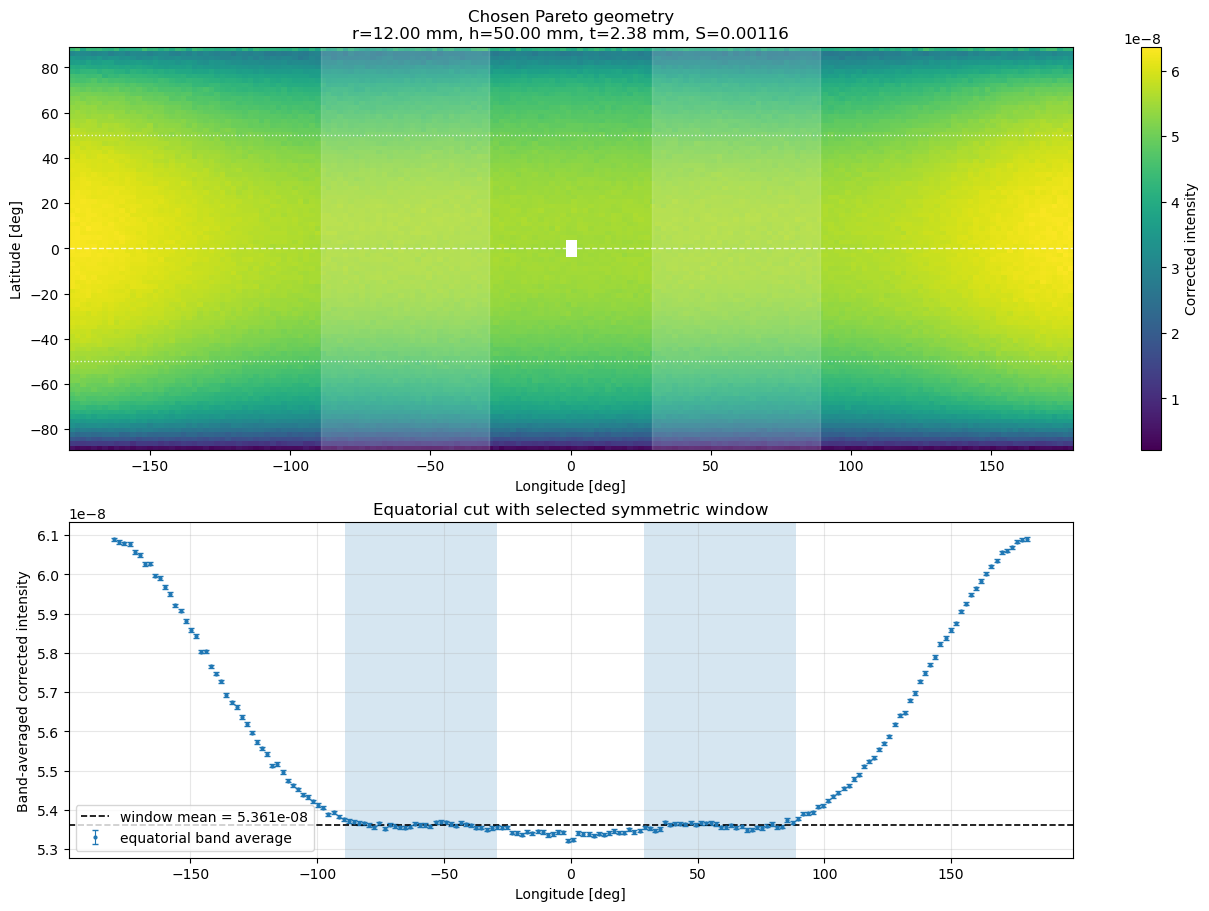

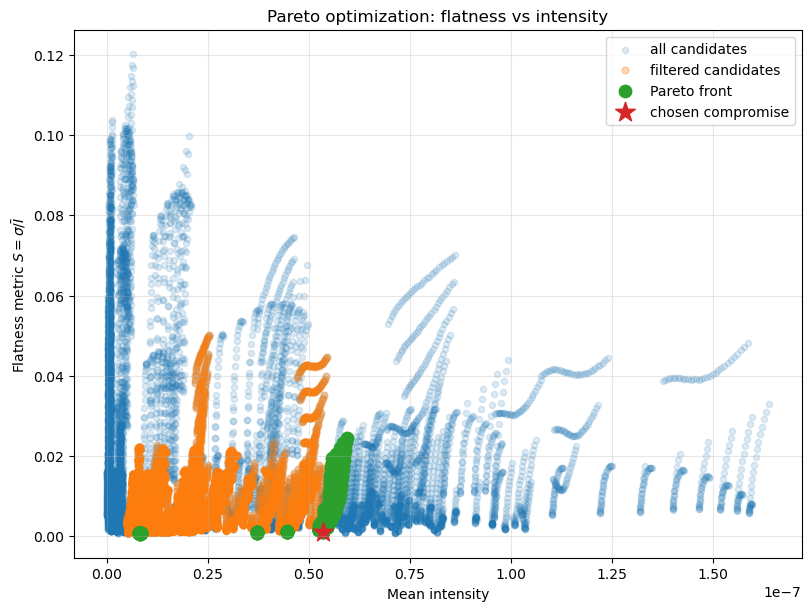

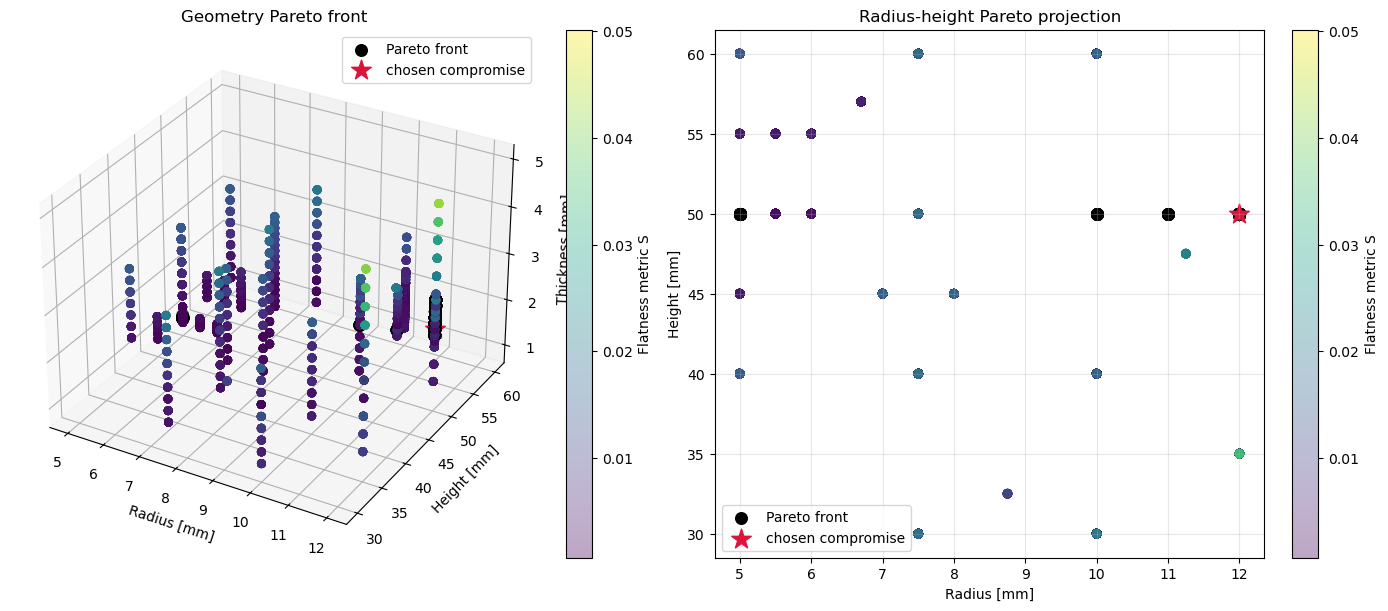

In [83]:
# ============================================================
# Flatness analysis + Pareto optimization
# ============================================================

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================

flatness_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/'
    'geometry_optimization/cylinder_instrument/flatness_test'
)

nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-30.0, 30.1, 2.0)

detector_window_width_deg = 60.0

low_outlier_fraction = 0.0

equator_band_halfwidth_local = 50.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0

# Feasibility filters
min_mean_intensity = 0.5e-8

radius_bounds_mm = (4, 12.0)
height_bounds_mm = (29.0, 61.0)
thickness_bounds_mm = (0.9, 5.1)

# ============================================================
# Helper functions
# ============================================================


def parse_mccode_sim(sim_file):

    params = {}

    pattern = re.compile(
        r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$'
    )

    with sim_file.open('r') as f:

        for line in f:

            match = pattern.match(line)

            if not match:
                continue

            key = match.group(1).strip()
            raw_value = match.group(2).strip()

            try:
                params[key] = float(raw_value)

            except ValueError:
                pass

    required = [
        'cylinder_radius',
        'cylinder_height',
        'thickness'
    ]

    missing = [k for k in required if k not in params]

    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    return {

        'outer_radius_mm':
            params['cylinder_radius'] * 1000.0,

        'outer_height_mm':
            params['cylinder_height'] * 1000.0,

        'wall_thickness_mm':
            params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(
            f'No McStas data loaded from {run_dir}'
        )

    for item in loaded:

        name = str(
            getattr(item, 'name', '') or ''
        )

        component = str(
            getattr(item, 'component_name', '') or ''
        )

        if (
            'cylinder_scattered' in name or
            'mon_4pi' in component
        ):
            return item

    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata

    H = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    H_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        H.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon_centers,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    H_corr = np.where(
        ~beam_center_mask,
        H_corr,
        np.nan
    )

    H_err_corr = np.where(
        ~beam_center_mask,
        H_err_corr,
        np.nan
    )

    return lon_centers, lat_centers, H_corr, H_err_corr


def get_equator_cut_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)

    meta = sphere_mon.metadata

    Hmc = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    Hmc_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        Hmc.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )

    lon = np.linspace(
        xmin,
        xmax,
        Hmc.shape[1]
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    Hmc_corrected = np.where(
        ~beam_center_mask,
        Hmc_corrected,
        np.nan
    )

    Hmc_err_corrected = np.where(
        ~beam_center_mask,
        Hmc_err_corrected,
        np.nan
    )

    equator_band_mask = (
        np.abs(lat_centers)
        <= equator_band_halfwidth_local
    )

    equator_band = Hmc_corrected[
        equator_band_mask,
        :
    ]

    equator_band_err = Hmc_err_corrected[
        equator_band_mask,
        :
    ]

    nonzero_band = equator_band > 0

    equator_band = np.where(
        nonzero_band,
        equator_band,
        np.nan
    )

    equator_band_err = np.where(
        nonzero_band,
        equator_band_err,
        np.nan
    )

    equator_cut = np.nanmean(
        equator_band,
        axis=0
    )

    valid_counts = np.sum(
        ~np.isnan(equator_band),
        axis=0
    )

    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(
            np.nansum(equator_band_err**2, axis=0)
        ) / valid_counts,
        np.nan,
    )

    valid_cols = (
        (valid_counts > 0)
        &
        np.isfinite(equator_cut)
        &
        (equator_cut > 0)
    )

    low_outlier_threshold = (
        low_outlier_fraction
        *
        np.nanmedian(equator_cut[valid_cols])
    )

    valid_cols = (
        valid_cols
        &
        (equator_cut >= low_outlier_threshold)
    )

    return (
        lon,
        equator_cut,
        equator_cut_err,
        valid_cols
    )


def s_score(lon, y, valid_cols, center_deg):

    half_width = detector_window_width_deg / 2.0

    pos_min = center_deg - half_width
    pos_max = center_deg + half_width

    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (
        (
            (lon >= pos_min)
            &
            (lon <= pos_max)
        )
        |
        (
            (lon >= neg_min)
            &
            (lon <= neg_max)
        )
    )

    y_fit = np.asarray(y)[fit_mask]

    y_fit = y_fit[
        np.isfinite(y_fit)
        &
        (y_fit > 0)
    ]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)

    sigma_window = np.std(
        y_fit,
        ddof=1
    )

    s_value = (
        sigma_window / mean_window
        if mean_window > 0 else np.nan
    )

    return {

        'center_deg':
            center_deg,

        'pos_min':
            pos_min,

        'pos_max':
            pos_max,

        'neg_min':
            neg_min,

        'neg_max':
            neg_max,

        'mean_window':
            mean_window,

        'sigma_window':
            sigma_window,

        'S':
            s_value,

        'n_points':
            len(y_fit),
    }


def pareto_front_indices(
    S_values,
    I_values,
    s_tol=0.05,
    i_tol=0.05,
):
    """
    Pareto front with tolerances.

    s_tol = required fractional improvement in S
    i_tol = required fractional improvement in intensity
    """

    S_values = np.asarray(S_values)
    I_values = np.asarray(I_values)

    n = len(S_values)

    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):

        if not is_pareto[i]:
            continue

        better_S = (
            S_values
            <=
            S_values[i] * (1.0 - s_tol)
        )

        better_I = (
            I_values
            >=
            I_values[i] * (1.0 + i_tol)
        )

        dominates = better_S & better_I

        dominates[i] = False

        if np.any(dominates):
            is_pareto[i] = False

    return np.where(is_pareto)[0]


# ============================================================
# Parse all runs
# ============================================================

sim_files = sorted(
    flatness_root.glob('**/mccode.sim')
)

records = []

for sim_file in sim_files:

    run_dir = sim_file.parent

    scatter_file = (
        run_dir / 'cylinder_scattered.dat'
    )

    if not scatter_file.exists():
        continue

    try:

        geom = parse_mccode_sim(sim_file)

        (
            lon,
            equator_cut,
            equator_cut_err,
            valid_cols
        ) = get_equator_cut_from_run(run_dir)

    except Exception:
        continue

    for offset_deg in center_offsets_deg:

        center_deg = (
            nominal_detector_center_deg
            +
            offset_deg
        )

        score = s_score(
            lon,
            equator_cut,
            valid_cols,
            center_deg
        )

        if score is None:
            continue

        score.update({

            'offset_deg':
                offset_deg,

            'run_dir':
                str(run_dir),

            'geometry_dir':
                str(run_dir.parent),

            'lon_plot':
                lon[valid_cols],

            'equator_cut_plot':
                equator_cut[valid_cols],

            'equator_cut_err_plot':
                equator_cut_err[valid_cols],

            **geom,
        })

        records.append(score)

print(f'Parsed candidate windows: {len(records)}')

# ============================================================
# Feasibility filtering
# ============================================================

records_unfiltered = records.copy()

records = [
    r for r in records
    if (
        r['mean_window'] >= min_mean_intensity
        and radius_bounds_mm[0] <= r['outer_radius_mm'] <= radius_bounds_mm[1]
        and height_bounds_mm[0] <= r['outer_height_mm'] <= height_bounds_mm[1]
        and thickness_bounds_mm[0] <= r['wall_thickness_mm'] <= thickness_bounds_mm[1]
    )
]

print(f'Candidate windows before filtering: {len(records_unfiltered)}')
print(f'Candidate windows after filtering:  {len(records)}')

# ============================================================
# Continue only if valid runs exist
# ============================================================

if not records:

    print('No valid runs found.')

else:

    # ========================================================
    # Pareto front
    # ========================================================

    S_all_unfiltered = np.array([r['S'] for r in records_unfiltered])
    I_all_unfiltered = np.array([r['mean_window'] for r in records_unfiltered])

    S_all = np.array([r['S'] for r in records])
    I_all = np.array([r['mean_window'] for r in records])

    pareto_idx = pareto_front_indices(
        S_all,
        I_all,
        s_tol=0.05,
        i_tol=0.05,
    )

    pareto_records = [
        records[i]
        for i in pareto_idx
    ]

    pareto_records = sorted(
        pareto_records,
        key=lambda r: r['S']
    )

    print(f'Pareto front size: {len(pareto_records)}')

    # ========================================================
    # Choose compromise point
    # ========================================================

    S_p = np.array([
        r['S']
        for r in pareto_records
    ])

    I_p = np.array([
        r['mean_window']
        for r in pareto_records
    ])

    S_norm = (
        S_p - S_p.min()
    ) / (
        S_p.max() - S_p.min() + 1e-30
    )

    I_norm = (
        I_p.max() - I_p
    ) / (
        I_p.max() - I_p.min() + 1e-30
    )

    distance_to_ideal = np.sqrt(
        S_norm**2 + I_norm**2
    )

    chosen = pareto_records[
        np.argmin(distance_to_ideal)
    ]

    print('\n--------------------------------------------------')
    print('Chosen Pareto compromise geometry')
    print('--------------------------------------------------')

    print(
        f"r = {chosen['outer_radius_mm']:.2f} mm, "
        f"h = {chosen['outer_height_mm']:.2f} mm, "
        f"t = {chosen['wall_thickness_mm']:.2f} mm"
    )

    print(
        f"S = {chosen['S']:.6f}, "
        f"mean = {chosen['mean_window']:.3e}, "
        f"sigma = {chosen['sigma_window']:.3e}, "
        f"offset = {chosen['offset_deg']:+.1f} deg"
    )

    # ========================================================
    # Print Pareto front
    # ========================================================

    print('\nTop Pareto solutions:\n')

    for i, r in enumerate(
        pareto_records[:20],
        start=1
    ):

        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"S={r['S']:.5f}, "
            f"mean={r['mean_window']:.3e}, "
            f"sigma={r['sigma_window']:.3e}"
        )

    # ========================================================
    # Load chosen geometry
    # ========================================================

    best = chosen

    best_run_dir = Path(best['run_dir'])

    (
        lon_best,
        lat_best,
        H_best,
        H_best_err
    ) = get_corrected_heatmap_from_run(best_run_dir)

    (
        lon_cut,
        equator_cut,
        equator_cut_err,
        valid_cols
    ) = get_equator_cut_from_run(best_run_dir)

    # ========================================================
    # Plot intensity map + equatorial cut
    # ========================================================

    fig, (ax_map, ax_cut) = plt.subplots(
        2,
        1,
        figsize=(12, 9),
        constrained_layout=True,
        gridspec_kw={
            'height_ratios': [1.2, 1.0]
        }
    )

    # --------------------------------------------------------
    # Heat map
    # --------------------------------------------------------

    im = ax_map.imshow(
        H_best,
        origin='lower',
        aspect='auto',
        extent=[
            lon_best.min(),
            lon_best.max(),
            lat_best.min(),
            lat_best.max()
        ],
        interpolation='nearest',
        cmap='viridis',
    )

    ax_map.axhline(
        0,
        color='white',
        linestyle='--',
        linewidth=1.0,
        alpha=0.8,
    )

    ax_map.axhline(
        +equator_band_halfwidth_local,
        color='white',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
    )

    ax_map.axhline(
        -equator_band_halfwidth_local,
        color='white',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:

        ax_map.axvspan(
            xmin_win,
            xmax_win,
            color='white',
            alpha=0.16,
        )

    ax_map.set_xlabel('Longitude [deg]')
    ax_map.set_ylabel('Latitude [deg]')

    ax_map.set_title(
        'Chosen Pareto geometry\n'
        f"r={best['outer_radius_mm']:.2f} mm, "
        f"h={best['outer_height_mm']:.2f} mm, "
        f"t={best['wall_thickness_mm']:.2f} mm, "
        f"S={best['S']:.5f}"
    )

    cbar = fig.colorbar(
        im,
        ax=ax_map
    )

    cbar.set_label(
        'Corrected intensity'
    )

    # --------------------------------------------------------
    # Equatorial cut
    # --------------------------------------------------------

    ax_cut.errorbar(
        lon_cut[valid_cols],
        equator_cut[valid_cols],
        yerr=equator_cut_err[valid_cols],
        fmt='.',
        markersize=4,
        capsize=2,
        linewidth=0.8,
        label='equatorial band average',
    )

    fit_mask = valid_cols & (
        (
            (lon_cut >= best['pos_min'])
            &
            (lon_cut <= best['pos_max'])
        )
        |
        (
            (lon_cut >= best['neg_min'])
            &
            (lon_cut <= best['neg_max'])
        )
    )

    fit_mean = np.nanmean(
        equator_cut[fit_mask]
    )

    ax_cut.axhline(
        fit_mean,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'window mean = {fit_mean:.3e}',
    )

    for xmin_win, xmax_win in [
        (best['pos_min'], best['pos_max']),
        (best['neg_min'], best['neg_max']),
    ]:

        ax_cut.axvspan(
            xmin_win,
            xmax_win,
            alpha=0.18,
        )

    ax_cut.set_xlabel(
        'Longitude [deg]'
    )

    ax_cut.set_ylabel(
        'Band-averaged corrected intensity'
    )

    ax_cut.set_title(
        'Equatorial cut with selected symmetric window'
    )

    ax_cut.grid(True, alpha=0.3)
    ax_cut.legend()

    plt.show()

    # ========================================================
    # Pareto plot
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(8, 6),
        constrained_layout=True
    )

    ax.scatter(
        I_all_unfiltered,
        S_all_unfiltered,
        s=20,
        alpha=0.15,
        label='all candidates'
    )

    ax.scatter(
        I_all,
        S_all,
        s=25,
        alpha=0.3,
        label='filtered candidates'
    )

    ax.scatter(
        [r['mean_window'] for r in pareto_records],
        [r['S'] for r in pareto_records],
        s=80,
        label='Pareto front'
    )

    ax.scatter(
        chosen['mean_window'],
        chosen['S'],
        marker='*',
        s=220,
        label='chosen compromise'
    )

    ax.set_xlabel(
        'Mean intensity'
    )

    ax.set_ylabel(
        r'Flatness metric $S=\sigma/\bar I$'
    )

    ax.set_title(
        'Pareto optimization: flatness vs intensity'
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    # ========================================================
    # Geometry plots
    # ========================================================

    fig = plt.figure(
        figsize=(14, 6),
        constrained_layout=True
    )

    # --------------------------------------------------------
    # 3D geometry plot
    # --------------------------------------------------------

    ax3d = fig.add_subplot(
        1,
        2,
        1,
        projection='3d'
    )

    sc = ax3d.scatter(

        [r['outer_radius_mm']
         for r in records],

        [r['outer_height_mm']
         for r in records],

        [r['wall_thickness_mm']
         for r in records],

        c=[r['S']
           for r in records],

        cmap='viridis',
        s=30,
        alpha=0.35,
    )

    ax3d.scatter(

        [r['outer_radius_mm']
         for r in pareto_records],

        [r['outer_height_mm']
         for r in pareto_records],

        [r['wall_thickness_mm']
         for r in pareto_records],

        color='black',
        s=70,
        label='Pareto front',
    )

    ax3d.scatter(

        chosen['outer_radius_mm'],
        chosen['outer_height_mm'],
        chosen['wall_thickness_mm'],

        color='crimson',
        marker='*',
        s=220,
        label='chosen compromise',
    )

    ax3d.set_xlabel('Radius [mm]')
    ax3d.set_ylabel('Height [mm]')
    ax3d.set_zlabel('Thickness [mm]')

    ax3d.set_title(
        'Geometry Pareto front'
    )

    ax3d.legend()

    fig.colorbar(
        sc,
        ax=ax3d,
        label='Flatness metric S'
    )

    # --------------------------------------------------------
    # 2D projection
    # --------------------------------------------------------

    ax2d = fig.add_subplot(1, 2, 2)

    proj = ax2d.scatter(

        [r['outer_radius_mm']
         for r in records],

        [r['outer_height_mm']
         for r in records],

        c=[r['S']
           for r in records],

        cmap='viridis',
        s=35,
        alpha=0.35,
    )

    ax2d.scatter(

        [r['outer_radius_mm']
         for r in pareto_records],

        [r['outer_height_mm']
         for r in pareto_records],

        color='black',
        s=70,
        label='Pareto front',
    )

    ax2d.scatter(

        chosen['outer_radius_mm'],
        chosen['outer_height_mm'],

        color='crimson',
        marker='*',
        s=220,
        label='chosen compromise',
    )

    ax2d.set_xlabel('Radius [mm]')
    ax2d.set_ylabel('Height [mm]')

    ax2d.set_title(
        'Radius-height Pareto projection'
    )

    ax2d.grid(True, alpha=0.3)
    ax2d.legend()

    fig.colorbar(
        proj,
        ax=ax2d,
        label='Flatness metric S'
    )

    plt.show()